In [1]:
# Cell 1 — Imports and load

In [2]:
import json, math, pathlib, sys
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT      = pathlib.Path('/home/zwadmin/GRASP')
DATA_DIR       = REPO_ROOT / 'sentinel' / 'data'
RESULTS_PATH   = DATA_DIR / 'reports' / 'gps_spoof' / 'results.json'
INVENTORY_PATH = DATA_DIR / 'corpus_inventory.json'
BIN_DIR        = DATA_DIR
PLOT_DIR       = DATA_DIR / 'reports' / 'gps_spoof'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from sentinel.core.parser import parse_file

with RESULTS_PATH.open() as fh:
    results = json.load(fh)
with INVENTORY_PATH.open() as fh:
    inventory = json.load(fh)

inv_index  = {r['file']: r for r in inventory}
clean      = [r for r in results if r['verdict'] == 'CLEAN']
suspicious = [r for r in results if r['verdict'] == 'SUSPICIOUS']
alert      = [r for r in results if r['verdict'] == 'ALERT']

print(f'Total: {len(results)}  Clean: {len(clean)}  Suspicious: {len(suspicious)}  Alert: {len(alert)}')
print('ALERT      :', [r['file'] for r in alert])
print('SUSPICIOUS :', [r['file'] for r in suspicious])

Total: 71  Clean: 68  Suspicious: 1  Alert: 2
ALERT      : ['00000048.BIN', '00000064.BIN']
SUSPICIOUS : ['00000010.BIN']


In [3]:
# Cell 2 — Distribution plot

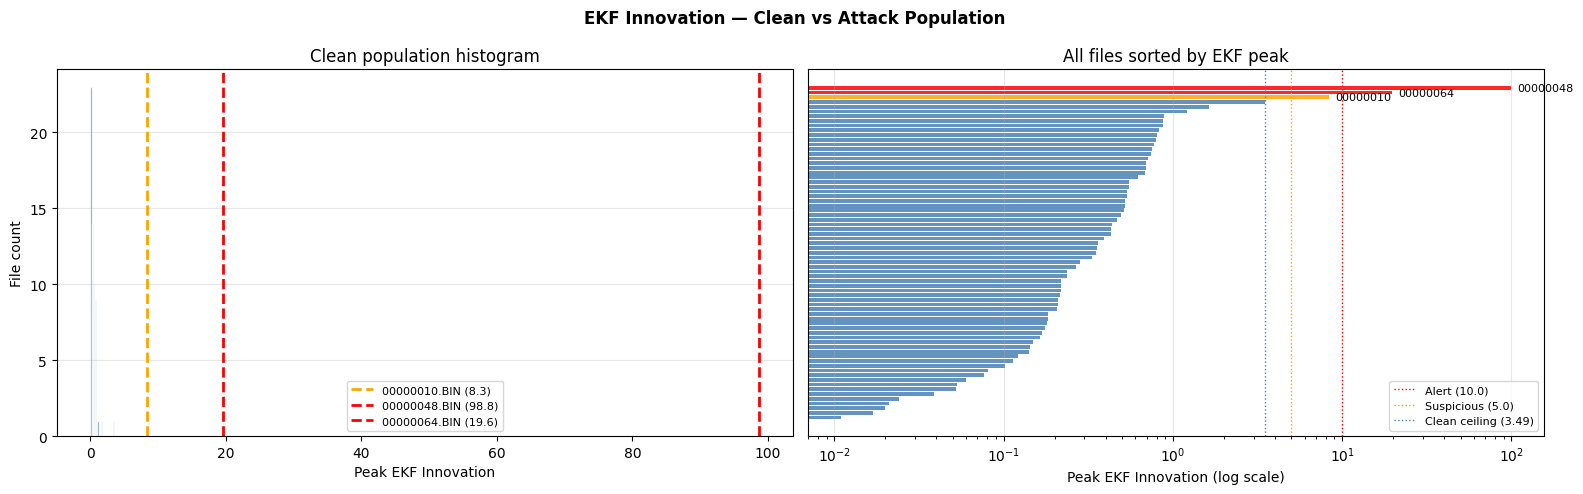

Clean ceiling: 3.488
Attack floor : 8.315


In [4]:
def ekf_max(r): return r['raw_values'].get('ekf_innov_max', 0.0)

all_sorted  = sorted(results, key=ekf_max)
vals        = [ekf_max(r) for r in all_sorted]
colours     = ['red' if r['verdict']=='ALERT' else 'orange' if r['verdict']=='SUSPICIOUS' else 'steelblue' for r in all_sorted]
clean_ceil  = max(ekf_max(r) for r in clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('EKF Innovation — Clean vs Attack Population', fontweight='bold')

# Left: histogram
axes[0].hist([ekf_max(r) for r in clean], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
for r in suspicious + alert:
    c = 'red' if r['verdict']=='ALERT' else 'orange'
    axes[0].axvline(ekf_max(r), color=c, linestyle='--', linewidth=2, label=f"{r['file']} ({ekf_max(r):.1f})")
axes[0].set_xlabel('Peak EKF Innovation')
axes[0].set_ylabel('File count')
axes[0].set_title('Clean population histogram')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Right: all files bar chart log scale
axes[1].barh(range(len(all_sorted)), vals, color=colours, alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_xlabel('Peak EKF Innovation (log scale)')
axes[1].set_title('All files sorted by EKF peak')
axes[1].set_yticks([])
for i, r in enumerate(all_sorted):
    if r['verdict'] in ('ALERT', 'SUSPICIOUS'):
        axes[1].text(vals[i]*1.1, i, r['file'].replace('.BIN',''), va='center', fontsize=8)
axes[1].axvline(10.0, color='red',       linestyle=':', linewidth=1, label='Alert (10.0)')
axes[1].axvline(5.0,  color='orange',    linestyle=':', linewidth=1, label='Suspicious (5.0)')
axes[1].axvline(clean_ceil, color='steelblue', linestyle=':', linewidth=1, label=f'Clean ceiling ({clean_ceil:.2f})')
axes[1].legend(fontsize=8)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_distribution.png', dpi=150)
plt.show()
print(f'Clean ceiling: {clean_ceil:.3f}')
print(f'Attack floor : {min(ekf_max(r) for r in suspicious+alert):.3f}')

In [5]:
# Cell 3 — Helper functions for time series

In [6]:
def ekf_timeseries(filepath):
    pr = parse_file(filepath)
    times, mags, t0 = [], [], None
    for msg in ('XKF1', 'NKF1'):
        for r in pr.records_by_type(msg):
            ts  = r.timeus
            ivn = float(r.get('IVN', r.get('VN', 0.0)))
            ive = float(r.get('IVE', r.get('VE', 0.0)))
            if ts is None: continue
            if t0 is None: t0 = ts
            times.append((ts - t0) / 1_000_000.0)
            mags.append(math.sqrt(ivn**2 + ive**2))
    return np.array(times), np.array(mags)

def motb_timeseries(filepath):
    pr = parse_file(filepath)
    times, vals, t0 = [], [], None
    for r in pr.records_by_type('MOTB'):
        ts  = r.timeus
        thr = r.get('ThO', r.get('ThrOut', 0.0))
        if ts is None: continue
        if t0 is None: t0 = ts
        times.append((ts - t0) / 1_000_000.0)
        vals.append(float(thr))
    return np.array(times), np.array(vals)

print('Helper functions ready.')

Helper functions ready.


In [7]:
# Cell 4 — Attack files time series

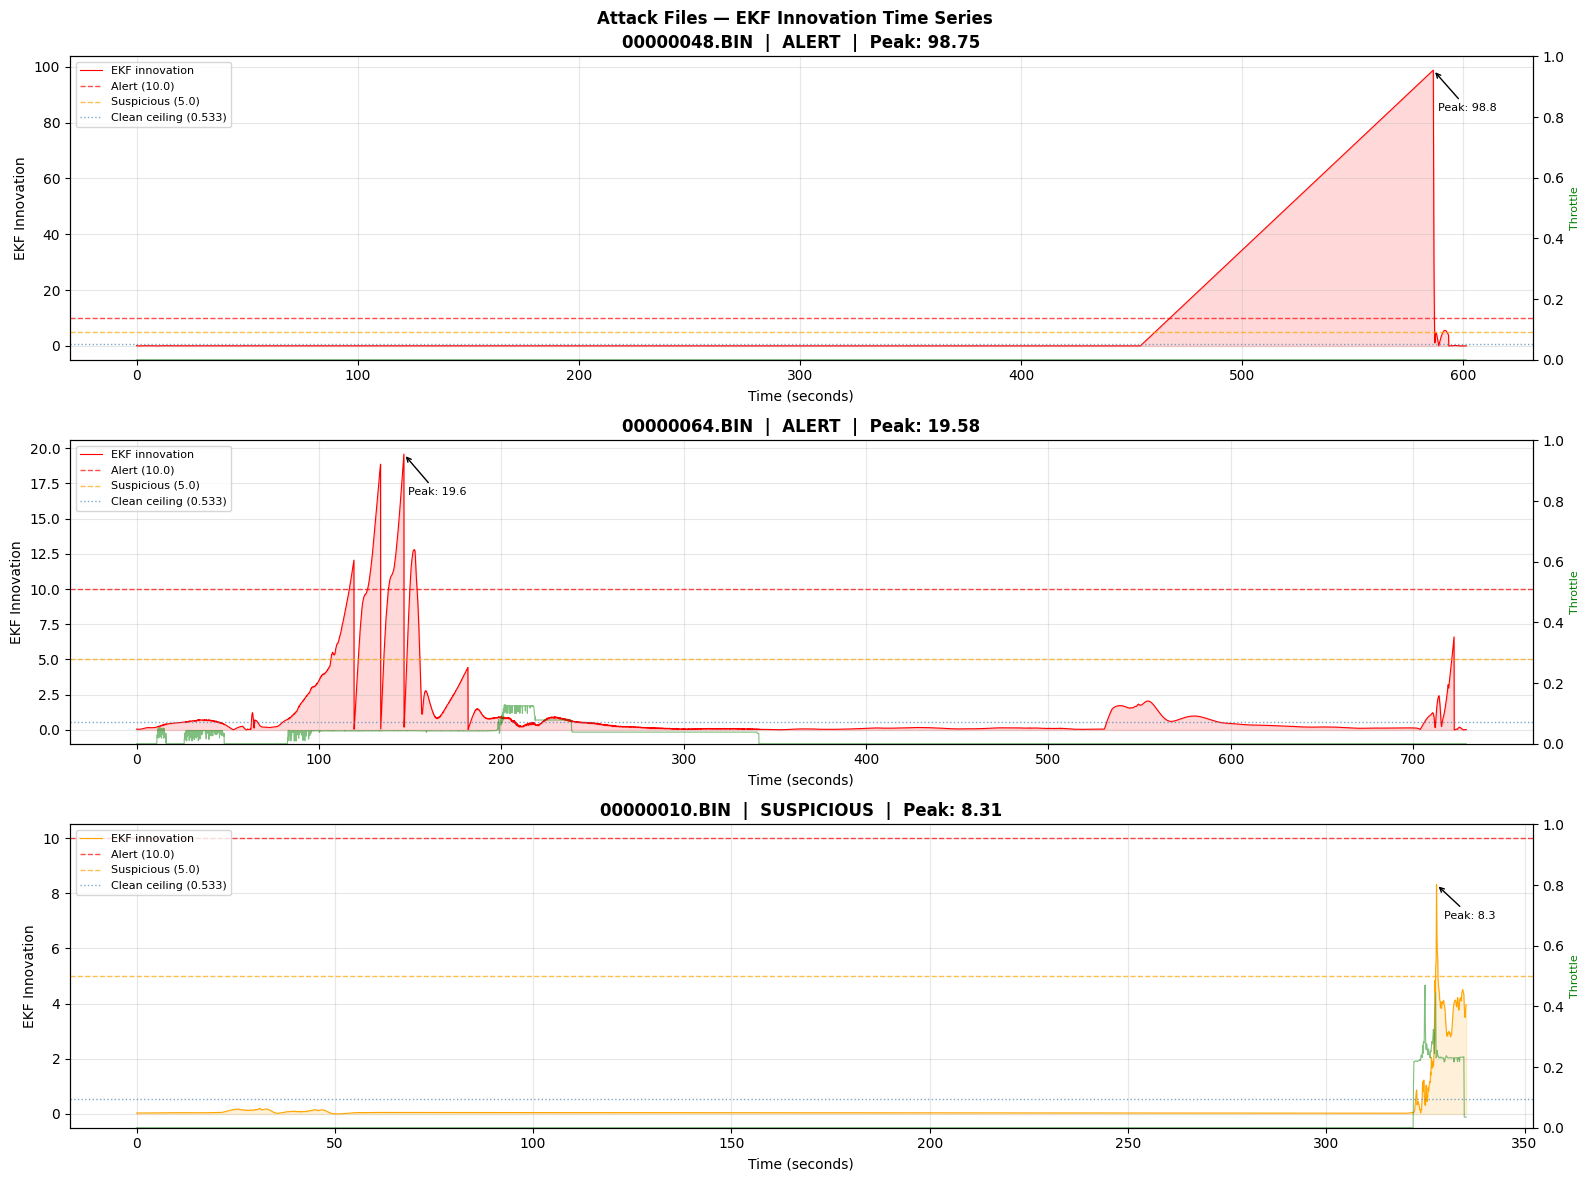

In [8]:
ATTACK_FILES = ['00000048.BIN', '00000064.BIN', '00000010.BIN']

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Attack Files — EKF Innovation Time Series', fontweight='bold')

for ax, fname in zip(axes, ATTACK_FILES):
    t_ekf, mag   = ekf_timeseries(BIN_DIR / fname)
    t_mot, throt = motb_timeseries(BIN_DIR / fname)
    res     = next(r for r in results if r['file'] == fname)
    verdict = res['verdict']
    colour  = 'red' if verdict == 'ALERT' else 'orange'

    ax.plot(t_ekf, mag, color=colour, linewidth=0.8, label='EKF innovation')
    ax.fill_between(t_ekf, mag, alpha=0.15, color=colour)
    ax.axhline(10.0,  color='red',       linestyle='--', linewidth=1, alpha=0.7, label='Alert (10.0)')
    ax.axhline(5.0,   color='orange',    linestyle='--', linewidth=1, alpha=0.7, label='Suspicious (5.0)')
    ax.axhline(0.533, color='steelblue', linestyle=':',  linewidth=1, alpha=0.7, label='Clean ceiling (0.533)')

    if len(t_mot) > 0:
        ax2 = ax.twinx()
        ax2.plot(t_mot, throt, color='green', linewidth=0.8, alpha=0.5)
        ax2.set_ylabel('Throttle', color='green', fontsize=8)
        ax2.set_ylim(0, 1.0)

    peak_idx = np.argmax(mag)
    ax.annotate(f"Peak: {mag[peak_idx]:.1f}",
                xy=(t_ekf[peak_idx], mag[peak_idx]),
                xytext=(t_ekf[peak_idx]+2, mag[peak_idx]*0.85),
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

    ax.set_title(f'{fname}  |  {verdict}  |  Peak: {res["raw_values"]["ekf_innov_max"]:.2f}', fontweight='bold')
    ax.set_ylabel('EKF Innovation')
    ax.set_xlabel('Time (seconds)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_attack_timeseries.png', dpi=150)
plt.show()

In [9]:
# Cell 5 — Baseline reference

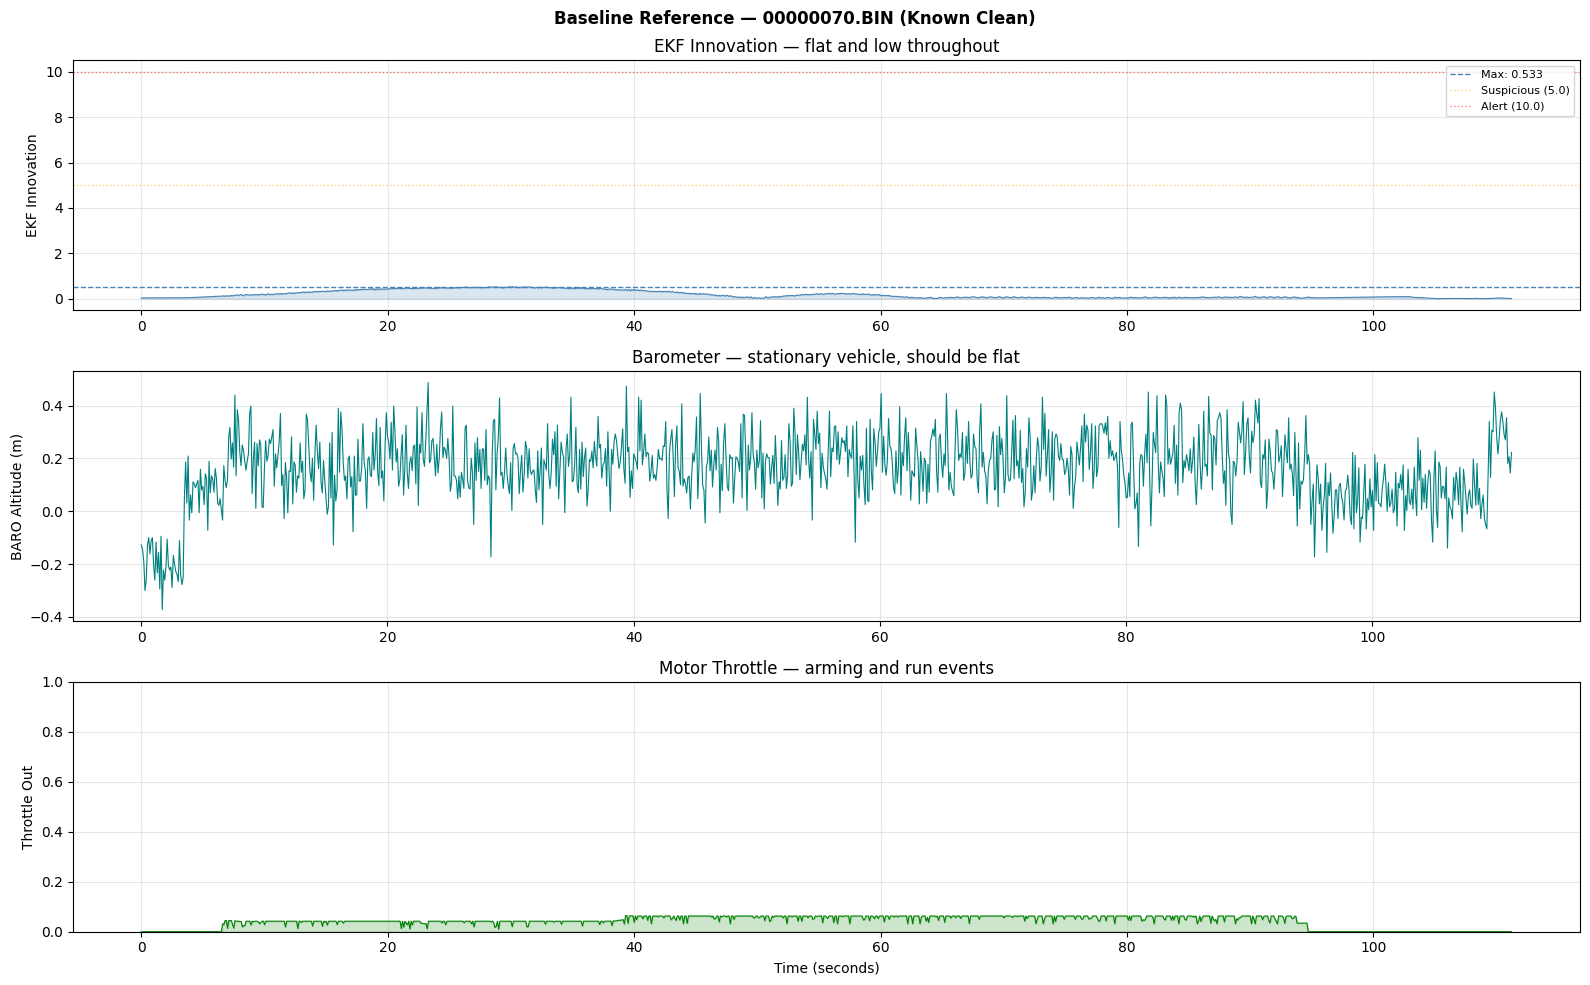

In [10]:
fpath = BIN_DIR / '00000070.BIN'
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle('Baseline Reference — 00000070.BIN (Known Clean)', fontweight='bold')

t_ekf, mag   = ekf_timeseries(fpath)
t_mot, throt = motb_timeseries(fpath)

pr = parse_file(fpath)
baro_t, baro_alt, t0 = [], [], None
for r in pr.records_by_type('BARO'):
    ts = r.timeus
    alt = r.get('Alt')
    if ts is None or alt is None: continue
    if t0 is None: t0 = ts
    baro_t.append((ts - t0) / 1_000_000.0)
    baro_alt.append(float(alt))

axes[0].plot(t_ekf, mag, color='steelblue', linewidth=0.8)
axes[0].fill_between(t_ekf, mag, alpha=0.2, color='steelblue')
axes[0].axhline(max(mag), color='steelblue', linestyle='--', linewidth=1, label=f'Max: {max(mag):.3f}')
axes[0].axhline(5.0,  color='orange', linestyle=':', linewidth=1, alpha=0.5, label='Suspicious (5.0)')
axes[0].axhline(10.0, color='red',    linestyle=':', linewidth=1, alpha=0.5, label='Alert (10.0)')
axes[0].set_ylabel('EKF Innovation')
axes[0].set_title('EKF Innovation — flat and low throughout')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(baro_t, baro_alt, color='teal', linewidth=0.8)
axes[1].set_ylabel('BARO Altitude (m)')
axes[1].set_title('Barometer — stationary vehicle, should be flat')
axes[1].grid(alpha=0.3)

axes[2].plot(t_mot, throt, color='green', linewidth=0.8)
axes[2].fill_between(t_mot, throt, alpha=0.2, color='green')
axes[2].set_ylabel('Throttle Out')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_title('Motor Throttle — arming and run events')
axes[2].set_ylim(0, 1.0)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_baseline.png', dpi=150)
plt.show()

In [11]:
# Cell 6 — Threshold sensitivity

Optimal threshold: 3.50


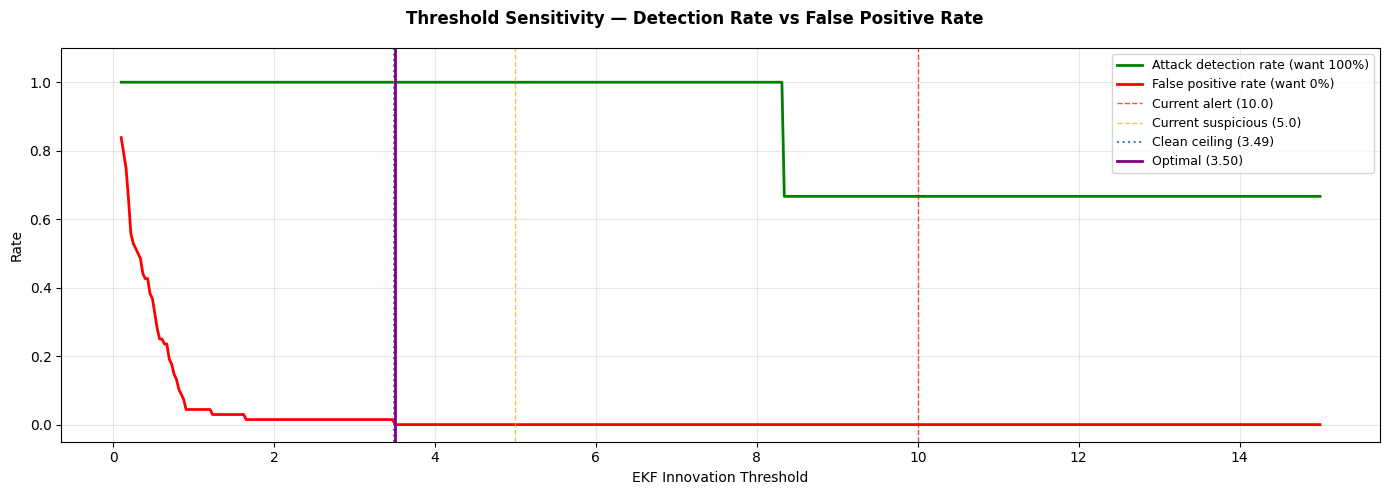

In [12]:
attack_vals = [ekf_max(r) for r in alert + suspicious]
clean_vals  = [ekf_max(r) for r in clean]
thresholds  = np.linspace(0.1, 15.0, 500)

tp_rate = [sum(1 for v in attack_vals if v > t) / len(attack_vals) for t in thresholds]
fp_rate = [sum(1 for v in clean_vals  if v > t) / len(clean_vals)  for t in thresholds]

# Find optimal
optimal = next((t for t, tp, fp in zip(thresholds, tp_rate, fp_rate) if fp == 0.0 and tp == 1.0), None)

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Threshold Sensitivity — Detection Rate vs False Positive Rate', fontweight='bold')
ax.plot(thresholds, tp_rate, color='green', linewidth=2, label='Attack detection rate (want 100%)')
ax.plot(thresholds, fp_rate, color='red',   linewidth=2, label='False positive rate (want 0%)')
ax.axvline(10.0, color='red',       linestyle='--', linewidth=1, alpha=0.7, label='Current alert (10.0)')
ax.axvline(5.0,  color='orange',    linestyle='--', linewidth=1, alpha=0.7, label='Current suspicious (5.0)')
ax.axvline(max(clean_vals), color='steelblue', linestyle=':', linewidth=1.5, label=f'Clean ceiling ({max(clean_vals):.2f})')
if optimal:
    ax.axvline(optimal, color='purple', linestyle='-', linewidth=2, label=f'Optimal ({optimal:.2f})')
    print(f'Optimal threshold: {optimal:.2f}')

ax.set_xlabel('EKF Innovation Threshold')
ax.set_ylabel('Rate')
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_threshold.png', dpi=150)
plt.show()